# Analisis de `data/latency_runs`

Este cuaderno analiza las corridas de latencia guardadas en `data/latency_runs/`.

**Enfoque experimental usado aqui**
- Se toma como dato del usuario que las **5 corridas usables mas recientes** corresponden al montaje con **LED rojo** en un ambiente **totalmente oscuro**.
- Las corridas anteriores se usan como referencia historica. Algunas incluyen otras condiciones de iluminacion o LED distinto.
- Varias corridas recientes tienen `summary` completo pero `results.csv` vacio por un problema de captura serial anterior; en esos casos se reconstruyen los trials visibles desde `latency_log_*.txt` y se usan los `summary` para las conclusiones por corrida.


In [1]:
from pathlib import Path
import csv
import re

import numpy as np
import pandas as pd
from pandas.errors import EmptyDataError
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['axes.labelsize'] = 12

BASE = Path('../data/latency_runs')


In [ ]:
def parse_timestamp_from_name(path):
    name = path.stem
    match = re.search(r'(\d{8}_\d{6}(?:_\d{2})?)$', name)
    return match.group(1) if match else None


def normalize_trial_df(df):
    if df.empty:
        return df

    df = df.copy()
    numeric_cols = [
        'trial', 'latency_us', 'freq_hz', 'adc', 'baseline_adc', 'threshold',
        'dark_level', 'lit_level', 'contrast'
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    if 'latency_us' in df.columns and 'freq_hz' not in df.columns:
        df['freq_hz'] = np.where(
            df['latency_us'] > 0,
            1_000_000.0 / df['latency_us'],
            np.nan,
        )

    if 'status' not in df.columns and 'latency_us' in df.columns:
        df['status'] = np.where(df['latency_us'].notna(), 'ok', 'timeout')

    return df


def read_trial_rows_from_log(log_path):
    rows = []
    header = None
    with open(log_path, 'r', encoding='utf-8', errors='ignore') as handle:
        for raw_line in handle:
            line = raw_line.strip()
            if line.startswith('CSV_HEADER,'):
                header = next(csv.reader([line[len('CSV_HEADER,'):]]))
                continue
            if line.startswith('CSV_ROW,'):
                rows.append(next(csv.reader([line[len('CSV_ROW,'):]])))
    if not rows:
        return pd.DataFrame()
    if header is None:
        header = [
            'trial', 'status', 'latency_us', 'freq_hz', 'adc', 'baseline_adc',
            'threshold', 'dark_level', 'lit_level', 'contrast', 'direction', 'mode'
        ]
    df = pd.DataFrame(rows, columns=header)
    return normalize_trial_df(df)


def load_latency_runs(base_dir):
    timestamps = set()
    for pattern in ('latency_results_*.csv', 'latency_summary_*.csv', 'latency_log_*.txt'):
        for path in base_dir.glob(pattern):
            ts = parse_timestamp_from_name(path)
            if ts:
                timestamps.add(ts)

    run_rows = []
    trial_frames = []
    empty_capture_rows = []

    for ts in sorted(timestamps):
        result_path = base_dir / f'latency_results_{ts}.csv'
        summary_path = base_dir / f'latency_summary_{ts}.csv'
        log_path = base_dir / f'latency_log_{ts}.txt'

        trial_df = pd.DataFrame()
        trial_source = None

        if result_path.exists():
            try:
                tmp = pd.read_csv(result_path)
                if not tmp.empty:
                    trial_df = normalize_trial_df(tmp)
                    trial_source = 'results_csv'
            except EmptyDataError:
                empty_capture_rows.append({'timestamp': ts, 'file': result_path.name, 'reason': 'empty_results_csv'})

        if trial_df.empty and log_path.exists():
            tmp = read_trial_rows_from_log(log_path)
            if not tmp.empty:
                trial_df = normalize_trial_df(tmp)
                trial_source = 'log_csv_rows'

        summary_df = pd.DataFrame()
        summary_source = None
        if summary_path.exists():
            try:
                tmp = pd.read_csv(summary_path)
                if not tmp.empty:
                    summary_df = tmp.copy()
                    summary_source = 'summary_csv'
            except EmptyDataError:
                empty_capture_rows.append({'timestamp': ts, 'file': summary_path.name, 'reason': 'empty_summary_csv'})

        if trial_df.empty and summary_df.empty:
            continue

        trial_rows_available = len(trial_df)
        if not trial_df.empty:
            trial_df = trial_df.copy()
            trial_df['timestamp'] = ts
            trial_frames.append(trial_df)

        trial_latency_median_us = np.nan
        trial_latency_mean_us = np.nan
        trial_freq_mean_hz = np.nan
        if not trial_df.empty and 'latency_us' in trial_df.columns:
            trial_latency_median_us = trial_df['latency_us'].median()
            trial_latency_mean_us = trial_df['latency_us'].mean()
        if not trial_df.empty and 'freq_hz' in trial_df.columns:
            trial_freq_mean_hz = trial_df['freq_hz'].mean()

        meta = {
            'timestamp': ts,
            'datetime': pd.to_datetime(ts, format='%Y%m%d_%H%M%S'),
            'trial_source': trial_source,
            'summary_source': summary_source,
            'trial_rows_available': trial_rows_available,
            'trial_rows_complete': trial_rows_available >= 50,
        }

        if not trial_df.empty:
            first = trial_df.iloc[0]
            meta.update({
                'dark_level': first.get('dark_level', np.nan),
                'lit_level': first.get('lit_level', np.nan),
                'contrast': first.get('contrast', np.nan),
                'direction': first.get('direction', None),
                'mode': first.get('mode', None),
                'trial_latency_median_us': trial_latency_median_us,
                'trial_latency_mean_us': trial_latency_mean_us,
                'trial_freq_mean_hz': trial_freq_mean_hz,
            })
        else:
            meta.update({
                'dark_level': np.nan,
                'lit_level': np.nan,
                'contrast': np.nan,
                'direction': None,
                'mode': None,
                'trial_latency_median_us': np.nan,
                'trial_latency_mean_us': np.nan,
                'trial_freq_mean_hz': np.nan,
            })

        if not summary_df.empty:
            summary_row = summary_df.iloc[0].to_dict()
            meta.update(summary_row)
        else:
            meta.update({
                'min_latency_us': np.nan,
                'max_latency_us': np.nan,
                'avg_latency_us': np.nan,
                'median_latency_us': np.nan,
                'failures': np.nan,
                'min_freq_hz': np.nan,
                'avg_freq_hz': np.nan,
                'median_freq_hz': np.nan,
                'max_freq_hz': np.nan,
            })

        run_rows.append(meta)

    runs = pd.DataFrame(run_rows).sort_values('datetime').reset_index(drop=True)
    trials = pd.concat(trial_frames, ignore_index=True) if trial_frames else pd.DataFrame()
    empty_captures = pd.DataFrame(empty_capture_rows)
    return runs, trials, empty_captures


runs, trials, empty_captures = load_latency_runs(BASE)
print('Corridas usables:', len(runs))
print('Trials visibles:', len(trials))
print('Capturas vacias detectadas:', len(empty_captures))


Corridas usables: 9
Trials visibles: 239
Capturas vacias detectadas: 10


In [3]:
runs[['timestamp', 'trial_source', 'summary_source', 'trial_rows_available', 'trial_rows_complete',
      'median_latency_us', 'avg_latency_us', 'median_freq_hz', 'contrast', 'dark_level', 'lit_level', 'direction', 'mode']]


,timestamp,trial_source,summary_source,trial_rows_available,trial_rows_complete,median_latency_us,avg_latency_us,median_freq_hz,contrast,dark_level,lit_level,direction,mode
0,20260430_121104,results_csv,summary_csv,50,True,607.0,675.580017,1647.446411,37,154,191,rising,threshold
1,20260430_122511,results_csv,summary_csv,50,True,1093.5,1069.959961,914.494751,309,0,309,rising,threshold
2,20260430_122532,results_csv,summary_csv,50,True,1104.0,1129.760010,905.797119,303,0,303,rising,threshold
3,20260430_122545,log_csv_rows,summary_csv,14,False,1181.0,1185.479980,846.740051,357,0,357,rising,threshold
4,20260430_122707,log_csv_rows,summary_csv,15,False,1848.0,1832.459961,541.125549,197,0,197,rising,threshold
5,20260430_122843,log_csv_rows,summary_csv,15,False,1937.5,1945.160034,516.129028,187,0,187,rising,threshold
6,20260430_122907,log_csv_rows,summary_csv,15,False,1844.0,1819.819946,542.299377,192,0,192,rising,threshold
7,20260430_122919,log_csv_rows,summary_csv,15,False,1935.0,1945.420044,516.795837,189,0,189,rising,threshold
8,20260430_122932,log_csv_rows,summary_csv,15,False,1993.0,1974.760010,501.756134,187,0,187,rising,threshold


In [4]:
empty_captures


,timestamp,file,reason
0,20260430_122215,latency_results_20260430_122215.csv,empty_results_csv
1,20260430_122215,latency_summary_20260430_122215.csv,empty_summary_csv
2,20260430_122246,latency_results_20260430_122246.csv,empty_results_csv
3,20260430_122246,latency_summary_20260430_122246.csv,empty_summary_csv
4,20260430_122545,latency_results_20260430_122545.csv,empty_results_csv
5,20260430_122707,latency_results_20260430_122707.csv,empty_results_csv
6,20260430_122843,latency_results_20260430_122843.csv,empty_results_csv
7,20260430_122907,latency_results_20260430_122907.csv,empty_results_csv
8,20260430_122919,latency_results_20260430_122919.csv,empty_results_csv
9,20260430_122932,latency_results_20260430_122932.csv,empty_results_csv


In [5]:
recent5 = runs.tail(5).copy()
recent5['group'] = 'recent_red_dark'
older = runs.iloc[:-5].copy()
older['group'] = 'older_reference'
comparison_runs = pd.concat([older, recent5], ignore_index=True)

recent5[['timestamp', 'median_latency_us', 'avg_latency_us', 'median_freq_hz', 'contrast', 'trial_rows_available', 'trial_source']]


,timestamp,median_latency_us,avg_latency_us,median_freq_hz,contrast,trial_rows_available,trial_source
4,20260430_122707,1848.0,1832.459961,541.125549,197,15,log_csv_rows
5,20260430_122843,1937.5,1945.160034,516.129028,187,15,log_csv_rows
6,20260430_122907,1844.0,1819.819946,542.299377,192,15,log_csv_rows
7,20260430_122919,1935.0,1945.420044,516.795837,189,15,log_csv_rows
8,20260430_122932,1993.0,1974.760010,501.756134,187,15,log_csv_rows


## Lectura rapida

- El bloque **reciente** se define como las **5 corridas usables mas recientes**.
- En este dataset son: `20260430_122707`, `20260430_122843`, `20260430_122907`, `20260430_122919`, `20260430_122932`.
- Para estas 5 corridas hay `summary` completo, pero los `trial` visibles se recuperan desde logs y no siempre estan los 50 trials completos. Por eso:
  - **las comparaciones por corrida** se apoyan sobre `latency_summary_*.csv`,
  - **las distribuciones por trial** se muestran solo como muestra visible de cada corrida.


In [6]:
group_summary = pd.DataFrame([
    {
        'group': 'older_reference',
        'runs': len(older),
        'median_of_median_latency_us': older['median_latency_us'].median(),
        'mean_of_avg_latency_us': older['avg_latency_us'].mean(),
        'median_of_median_freq_hz': older['median_freq_hz'].median(),
        'mean_of_avg_freq_hz': older['avg_freq_hz'].mean(),
        'mean_contrast': older['contrast'].mean(),
    },
    {
        'group': 'recent_red_dark',
        'runs': len(recent5),
        'median_of_median_latency_us': recent5['median_latency_us'].median(),
        'mean_of_avg_latency_us': recent5['avg_latency_us'].mean(),
        'median_of_median_freq_hz': recent5['median_freq_hz'].median(),
        'mean_of_avg_freq_hz': recent5['avg_freq_hz'].mean(),
        'mean_contrast': recent5['contrast'].mean(),
    },
])
group_summary


,group,runs,median_of_median_latency_us,mean_of_avg_latency_us,median_of_median_freq_hz,mean_of_avg_freq_hz,mean_contrast
0,older_reference,4,1098.75,1015.194992,910.145935,1035.876984,251.5
1,recent_red_dark,5,1935.00,1903.523999,516.795837,525.946881,190.4


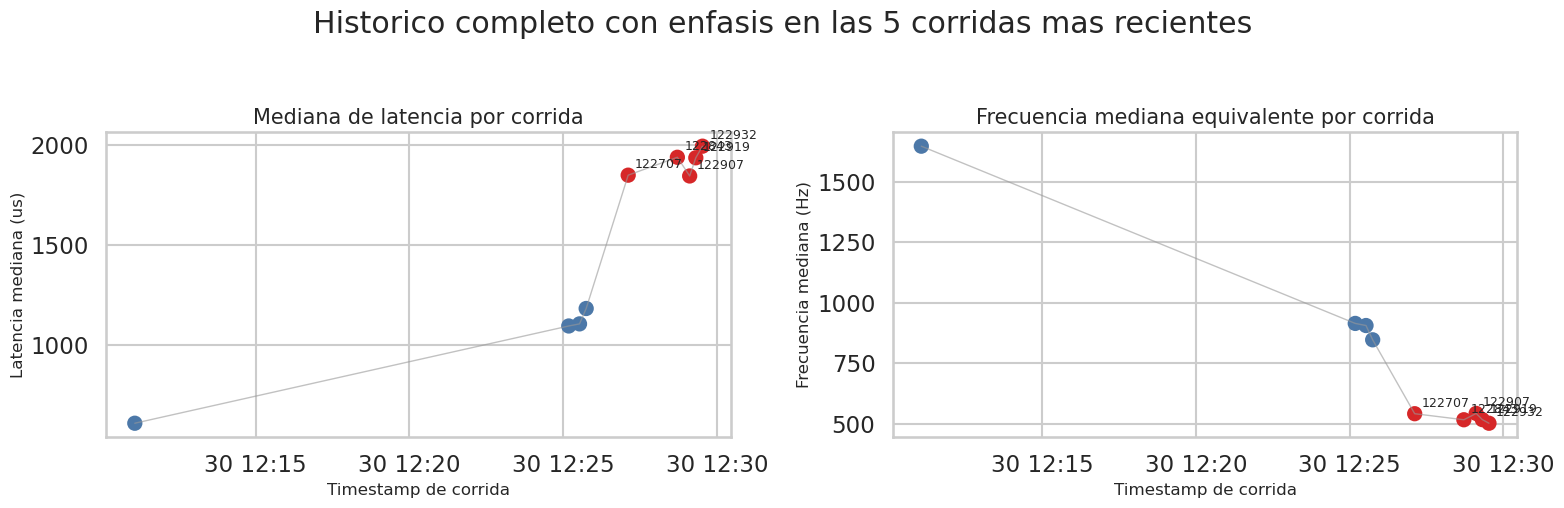

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_df = runs.copy()
plot_df['is_recent5'] = plot_df['timestamp'].isin(recent5['timestamp'])
colors = plot_df['is_recent5'].map({True: '#d62728', False: '#4c78a8'})

axes[0].plot(plot_df['datetime'], plot_df['median_latency_us'], color='#999999', linewidth=1, alpha=0.6)
axes[0].scatter(plot_df['datetime'], plot_df['median_latency_us'], c=colors, s=90)
for _, row in plot_df.iterrows():
    if row['is_recent5']:
        axes[0].annotate(row['timestamp'][-6:], (row['datetime'], row['median_latency_us']), textcoords='offset points', xytext=(5, 5), fontsize=9)
axes[0].set_title('Mediana de latencia por corrida')
axes[0].set_ylabel('Latencia mediana (us)')
axes[0].set_xlabel('Timestamp de corrida')

axes[1].plot(plot_df['datetime'], plot_df['median_freq_hz'], color='#999999', linewidth=1, alpha=0.6)
axes[1].scatter(plot_df['datetime'], plot_df['median_freq_hz'], c=colors, s=90)
for _, row in plot_df.iterrows():
    if row['is_recent5']:
        axes[1].annotate(row['timestamp'][-6:], (row['datetime'], row['median_freq_hz']), textcoords='offset points', xytext=(5, 5), fontsize=9)
axes[1].set_title('Frecuencia mediana equivalente por corrida')
axes[1].set_ylabel('Frecuencia mediana (Hz)')
axes[1].set_xlabel('Timestamp de corrida')

fig.suptitle('Historico completo con enfasis en las 5 corridas mas recientes', y=1.03)
plt.tight_layout()


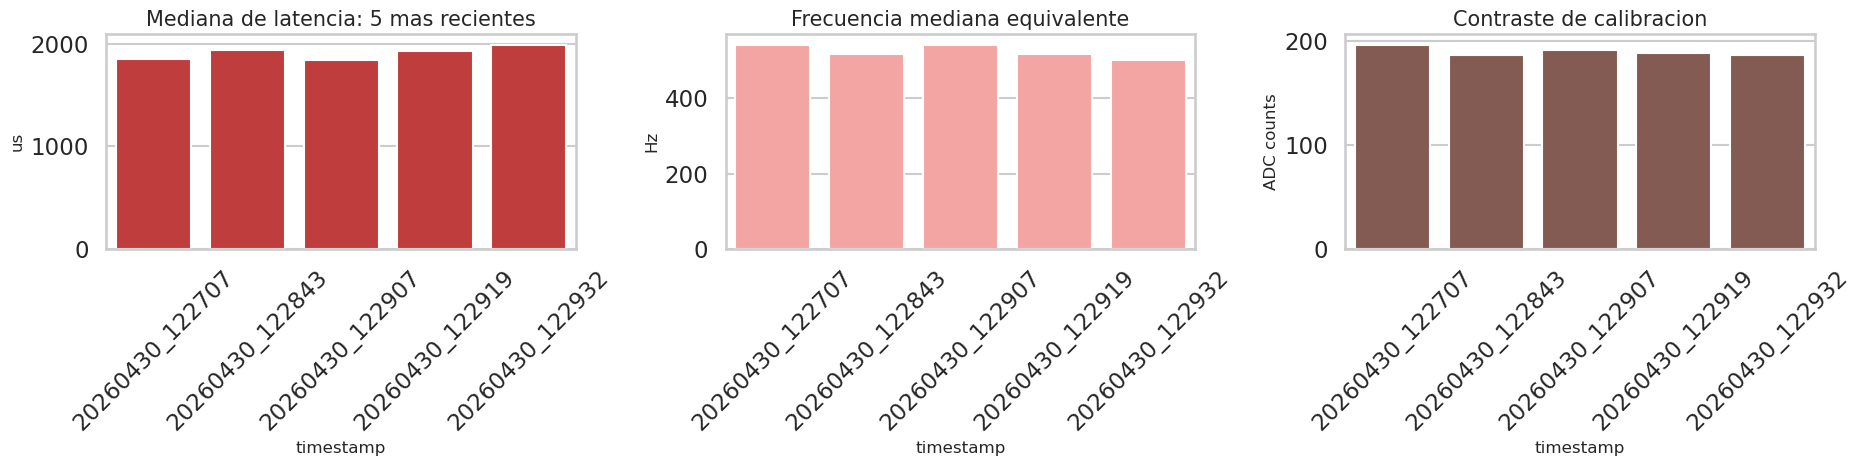

In [8]:
recent5_plot = recent5.sort_values('datetime').copy()
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

sns.barplot(data=recent5_plot, x='timestamp', y='median_latency_us', color='#d62728', ax=axes[0])
axes[0].set_title('Mediana de latencia: 5 mas recientes')
axes[0].set_ylabel('us')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=recent5_plot, x='timestamp', y='median_freq_hz', color='#ff9896', ax=axes[1])
axes[1].set_title('Frecuencia mediana equivalente')
axes[1].set_ylabel('Hz')
axes[1].tick_params(axis='x', rotation=45)

sns.barplot(data=recent5_plot, x='timestamp', y='contrast', color='#8c564b', ax=axes[2])
axes[2].set_title('Contraste de calibracion')
axes[2].set_ylabel('ADC counts')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()


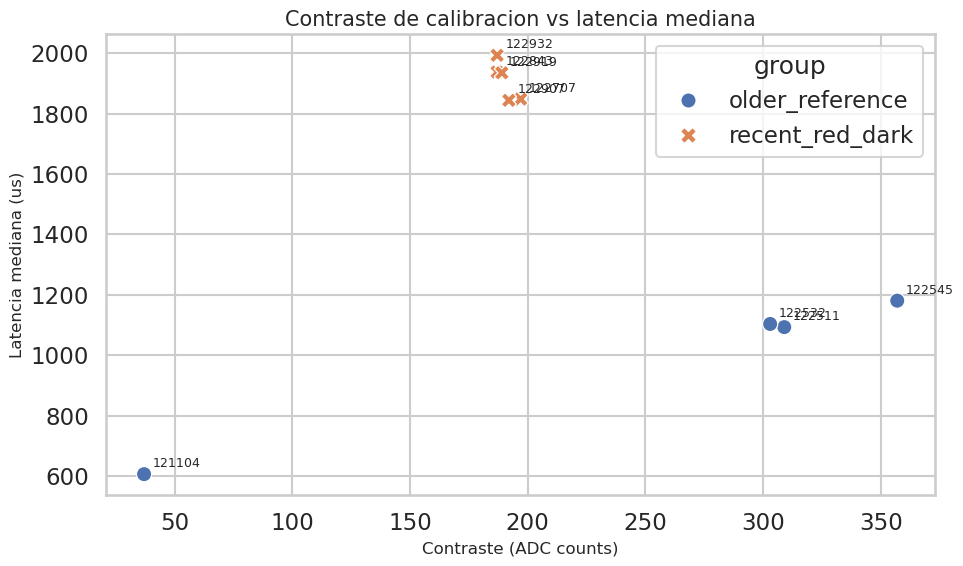

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
scatter_df = runs.copy()
scatter_df['label'] = scatter_df['timestamp'].str[-6:]
scatter_df['group'] = np.where(scatter_df['timestamp'].isin(recent5['timestamp']), 'recent_red_dark', 'older_reference')
sns.scatterplot(data=scatter_df, x='contrast', y='median_latency_us', hue='group', style='group', s=120, ax=ax)
for _, row in scatter_df.iterrows():
    ax.annotate(row['label'], (row['contrast'], row['median_latency_us']), textcoords='offset points', xytext=(6, 5), fontsize=9)
ax.set_title('Contraste de calibracion vs latencia mediana')
ax.set_xlabel('Contraste (ADC counts)')
ax.set_ylabel('Latencia mediana (us)')
plt.tight_layout()


In [10]:
trial_plot = trials[trials['timestamp'].isin(recent5['timestamp'])].copy()
recent_order = recent5.sort_values('datetime')['timestamp'].tolist()
trial_counts = trial_plot.groupby('timestamp').size().rename('visible_trials')
trial_counts


timestamp
20260430_122707    15
20260430_122843    15
20260430_122907    15
20260430_122919    15
20260430_122932    15
Name: visible_trials, dtype: int64

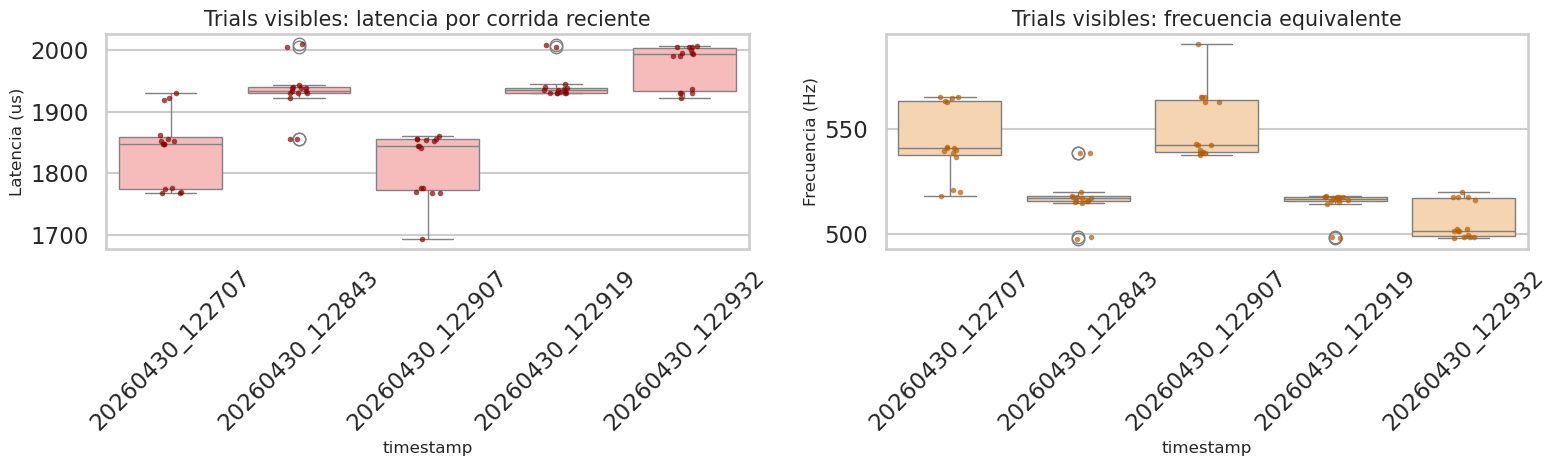

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
if not trial_plot.empty:
    sns.boxplot(data=trial_plot, x='timestamp', y='latency_us', order=recent_order, color='#ffb3b3', ax=axes[0])
    sns.stripplot(data=trial_plot, x='timestamp', y='latency_us', order=recent_order, color='#8b0000', size=4, alpha=0.7, ax=axes[0])
    axes[0].set_title('Trials visibles: latencia por corrida reciente')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].set_ylabel('Latencia (us)')

    sns.boxplot(data=trial_plot, x='timestamp', y='freq_hz', order=recent_order, color='#ffd5a6', ax=axes[1])
    sns.stripplot(data=trial_plot, x='timestamp', y='freq_hz', order=recent_order, color='#b85c00', size=4, alpha=0.7, ax=axes[1])
    axes[1].set_title('Trials visibles: frecuencia equivalente')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].set_ylabel('Frecuencia (Hz)')
else:
    axes[0].text(0.5, 0.5, 'No hay trial rows visibles para las 5 recientes', ha='center', va='center')
    axes[1].text(0.5, 0.5, 'No hay trial rows visibles para las 5 recientes', ha='center', va='center')
plt.tight_layout()


In [12]:
display_cols = ['timestamp', 'datetime', 'median_latency_us', 'avg_latency_us', 'median_freq_hz', 'avg_freq_hz',
                'contrast', 'dark_level', 'lit_level', 'trial_rows_available', 'trial_source']
recent5[display_cols].sort_values('datetime')

,timestamp,datetime,median_latency_us,avg_latency_us,median_freq_hz,avg_freq_hz,contrast,dark_level,lit_level,trial_rows_available,trial_source
4,20260430_122707,2026-04-30 12:27:07,1848.0,1832.459961,541.125549,545.714539,197,0,197,15,log_csv_rows
5,20260430_122843,2026-04-30 12:28:43,1937.5,1945.160034,516.129028,514.096497,187,0,187,15,log_csv_rows
6,20260430_122907,2026-04-30 12:29:07,1844.0,1819.819946,542.299377,549.504883,192,0,192,15,log_csv_rows
7,20260430_122919,2026-04-30 12:29:19,1935.0,1945.420044,516.795837,514.027832,189,0,189,15,log_csv_rows
8,20260430_122932,2026-04-30 12:29:32,1993.0,1974.760010,501.756134,506.390656,187,0,187,15,log_csv_rows


## Conclusiones principales

1. **Las 5 corridas usables mas recientes son claramente mas lentas que el bloque anterior**.
   - El bloque historico usable anterior tiene una mediana de corridas alrededor de **1098.75 us** y una frecuencia mediana equivalente alrededor de **910.15 Hz**.
   - El bloque reciente (LED rojo en oscuro, segun la nota experimental) sube a una mediana de corridas alrededor de **1935 us** y baja a una frecuencia mediana equivalente alrededor de **516.80 Hz**.

2. **El bloque reciente es ademas bastante consistente entre corridas**.
   - Las medianas por corrida del bloque reciente quedan agrupadas aproximadamente entre **1844 us** y **1993 us**.
   - Eso sugiere que, bajo ese montaje oscuro con LED rojo, la plataforma se estabiliza alrededor de **0.5 kHz a 0.57 kHz** de frecuencia equivalente, bastante por debajo de las corridas anteriores mas rapidas.

3. **El contraste de calibracion no explica por si solo toda la diferencia**.
   - Las corridas anteriores intermedias llegan a contrastes altos (~303-357 ADC counts) con latencias cercanas a **1.07-1.19 ms**.
   - Las 5 mas recientes muestran contrastes mas modestos (~187-197) y latencias cerca de **1.85-1.99 ms**. Hay una asociacion visible: menos contraste y mas latencia en ese bloque reciente.

4. **La completitud de los trials visibles no es uniforme**.
   - Para varias corridas recientes, el `summary` contiene la corrida completa, pero solo una parte de los `CSV_ROW` quedo registrada en los logs capturados. Por eso, las conclusiones de comparacion entre corridas deben apoyarse principalmente en `latency_summary_*.csv`.

5. **Interpretacion tecnica sugerida**.
   - Estos numeros describen la respuesta del **montaje completo** (LED + fototransistor + resistencia + ADC + polling en MicroPython), no la respuesta intrinseca aislada del OP598.
   - Para reportar el experimento reciente, la cifra mas defendible es la **latencia mediana por corrida** del bloque reciente: aproximadamente **1.94 ms**, equivalente a aproximadamente **517 Hz**.


---

## Sesión de tarde — corridas desde las 16:20 y destellos

Esta sección incorpora las mediciones realizadas a partir de las 16:20 del mismo día.

**Cambios respecto al bloque anterior:**
- El formato de los archivos de resultados es simplificado: solo `trial, latency_us, adc` (sin campos de calibración ni modo).
- Se incorpora un nuevo tipo de corrida con prefijo `destello_`, orientado a medir el retardo ante un pulso de luz tipo destello.
- 4 de las 8 corridas del bloque regular están vacías o sin datos de latencia utilizables.

**Corridas regulares nuevas (timestamps del bloque tarde):**

| Timestamp | Estado |
|-----------|--------|
| 162158 | Sin datos de latencia (solo ADC en log) |
| 170139 | Completamente vacía |
| 170425 | Completamente vacía |
| 170905 | Completamente vacía |
| 171805 | ✓ 50 trials completos |
| 172251 | ✓ 50 trials completos |
| 172351 | ✓ 50 trials completos |
| 172434 | ✓ 50 trials completos |

**Corridas de destellos (prefijo `destello_latency_`):**

| Timestamp | Estado |
|-----------|--------|
| 174041 | 5 timeouts — sin datos |
| 174118 | 5 timeouts — sin datos |
| 174211 | ✓ 5 trials completos |

In [ ]:
def load_simple_run(ts, base_dir=BASE, prefix='latency'):
    """Carga un run del formato simplificado: trial, latency_us, adc."""
    result_path = base_dir / f'{prefix}_results_{ts}.csv'
    summary_path = base_dir / f'{prefix}_summary_{ts}.csv'

    trial_df = pd.DataFrame()
    if result_path.exists():
        try:
            tmp = pd.read_csv(result_path)
            if not tmp.empty and 'latency_us' in tmp.columns:
                tmp['latency_us'] = pd.to_numeric(tmp['latency_us'], errors='coerce')
                tmp = tmp.dropna(subset=['latency_us'])
                if not tmp.empty:
                    tmp['freq_hz'] = 1_000_000.0 / tmp['latency_us']
                    trial_df = tmp.copy()
        except Exception:
            pass

    summary_df = pd.DataFrame()
    if summary_path.exists():
        try:
            tmp = pd.read_csv(summary_path)
            if not tmp.empty:
                row = tmp.iloc[0]
                if pd.notna(row.get('median_latency_us')):
                    summary_df = tmp.copy()
        except Exception:
            pass

    meta = {
        'timestamp': ts,
        'datetime': pd.to_datetime(ts, format='%Y%m%d_%H%M%S'),
        'trial_rows': len(trial_df),
        'has_data': not trial_df.empty,
    }

    if not summary_df.empty:
        row = summary_df.iloc[0]
        meta['failures'] = pd.to_numeric(row.get('failures', np.nan), errors='coerce')
        meta['median_latency_us'] = pd.to_numeric(row.get('median_latency_us', np.nan), errors='coerce')
        meta['avg_latency_us'] = pd.to_numeric(row.get('avg_latency_us', np.nan), errors='coerce')
        meta['median_freq_hz'] = pd.to_numeric(row.get('median_freq_hz', np.nan), errors='coerce')
        meta['avg_freq_hz'] = pd.to_numeric(row.get('avg_freq_hz', np.nan), errors='coerce')
        meta['min_latency_us'] = pd.to_numeric(row.get('min_latency_us', np.nan), errors='coerce')
        meta['max_latency_us'] = pd.to_numeric(row.get('max_latency_us', np.nan), errors='coerce')
    elif not trial_df.empty:
        meta['failures'] = 0
        meta['median_latency_us'] = trial_df['latency_us'].median()
        meta['avg_latency_us'] = trial_df['latency_us'].mean()
        meta['median_freq_hz'] = trial_df['freq_hz'].median()
        meta['avg_freq_hz'] = trial_df['freq_hz'].mean()
        meta['min_latency_us'] = trial_df['latency_us'].min()
        meta['max_latency_us'] = trial_df['latency_us'].max()
    else:
        for k in ['failures', 'median_latency_us', 'avg_latency_us', 'median_freq_hz',
                  'avg_freq_hz', 'min_latency_us', 'max_latency_us']:
            meta[k] = np.nan

    return meta, trial_df


# Corridas regulares del bloque tarde
new_ts_list = [
    '20260430_162158', '20260430_170139', '20260430_170425', '20260430_170905',
    '20260430_171805', '20260430_172251', '20260430_172351', '20260430_172434',
]

new_run_rows = []
new_trial_frames = []
for ts in new_ts_list:
    meta, tdf = load_simple_run(ts)
    new_run_rows.append(meta)
    if not tdf.empty:
        tdf = tdf.copy()
        tdf['timestamp'] = ts
        new_trial_frames.append(tdf)

new_runs = pd.DataFrame(new_run_rows).sort_values('datetime').reset_index(drop=True)
new_trials = pd.concat(new_trial_frames, ignore_index=True) if new_trial_frames else pd.DataFrame()

usable_new = new_runs[new_runs['has_data']].copy()
print(f'Corridas nuevas totales: {len(new_runs)} | Usables: {len(usable_new)} | Vacías: {len(new_runs) - len(usable_new)}')
print(f'Trials totales: {len(new_trials)}')


In [ ]:
new_runs[['timestamp', 'trial_rows', 'has_data', 'failures',
          'median_latency_us', 'avg_latency_us', 'min_latency_us', 'max_latency_us',
          'median_freq_hz']].sort_values('timestamp')

In [ ]:
usable_order = usable_new.sort_values('datetime')['timestamp'].tolist()
usable_labels = [ts[-6:] for ts in usable_order]

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

colors_new = ['#2ca02c', '#d62728', '#d62728', '#1f77b4']

sns.barplot(data=usable_new.sort_values('datetime'), x='timestamp', y='median_latency_us',
            palette=colors_new, ax=axes[0])
axes[0].set_xticklabels(usable_labels, rotation=30)
axes[0].set_title('Latencia mediana — corridas usables (tarde)')
axes[0].set_ylabel('Latencia mediana (us)')
axes[0].set_xlabel('Timestamp (HHMMSS)')

sns.barplot(data=usable_new.sort_values('datetime'), x='timestamp', y='median_freq_hz',
            palette=colors_new, ax=axes[1])
axes[1].set_xticklabels(usable_labels, rotation=30)
axes[1].set_title('Frecuencia mediana equivalente (tarde)')
axes[1].set_ylabel('Frecuencia mediana (Hz)')
axes[1].set_xlabel('Timestamp (HHMMSS)')

trial_plot_new = new_trials[new_trials['timestamp'].isin(usable_order)].copy()
if not trial_plot_new.empty:
    trial_palette = dict(zip(usable_order, colors_new))
    sns.boxplot(data=trial_plot_new, x='timestamp', y='latency_us', order=usable_order,
                palette=trial_palette, ax=axes[2])
    sns.stripplot(data=trial_plot_new, x='timestamp', y='latency_us', order=usable_order,
                  color='#333333', size=3, alpha=0.5, ax=axes[2])
    axes[2].set_xticklabels(usable_labels, rotation=30)
    axes[2].set_title('Distribución por trial — corridas usables (tarde)')
    axes[2].set_ylabel('Latencia (us)')
    axes[2].set_xlabel('Timestamp (HHMMSS)')

fig.suptitle('Bloque tarde: 4 corridas usables (verde=rápida, azul=ultrarrápida, rojo=lentas)', y=1.02)
plt.tight_layout()


### Corridas de destellos (17:40)

Las corridas de tipo `destello_` usan un protocolo de medición diferente: el sensor espera un pulso de luz tipo destello (no una señal continua). Los archivos tienen el prefijo `destello_latency_`.

- `174041` y `174118`: 5 timeouts cada una — el sensor no detectó el destello en ningún trial.
- `174211`: 5 trials exitosos — primera corrida de destello con datos válidos.

In [ ]:
destello_ts_list = ['20260430_174041', '20260430_174118', '20260430_174211']

destello_run_rows = []
destello_trial_frames = []
for ts in destello_ts_list:
    meta, tdf = load_simple_run(ts, prefix='destello_latency')
    meta['type'] = 'destello'
    destello_run_rows.append(meta)
    if not tdf.empty:
        tdf = tdf.copy()
        tdf['timestamp'] = ts
        destello_trial_frames.append(tdf)

destello_runs = pd.DataFrame(destello_run_rows).sort_values('datetime').reset_index(drop=True)
destello_trials = pd.concat(destello_trial_frames, ignore_index=True) if destello_trial_frames else pd.DataFrame()

print(f'Corridas destello: {len(destello_runs)} | Con datos: {destello_runs["has_data"].sum()}')
destello_runs[['timestamp', 'trial_rows', 'has_data', 'failures',
               'median_latency_us', 'avg_latency_us', 'min_latency_us', 'max_latency_us',
               'median_freq_hz']]


In [ ]:
# Comparar distribución de trials: 172434 (regular ultrarrápida) vs destello 174211
fast_ts = '20260430_172434'
destello_ok_ts = '20260430_174211'

fast_trials = new_trials[new_trials['timestamp'] == fast_ts].copy()
destello_ok_trials = destello_trials[destello_trials['timestamp'] == destello_ok_ts].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, label, color in [
    (axes[0], fast_trials, f'Regular 172434\n(50 trials)', '#1f77b4'),
    (axes[1], destello_ok_trials, f'Destello 174211\n(5 trials)', '#ff7f0e'),
]:
    if df.empty:
        ax.text(0.5, 0.5, 'Sin datos', ha='center', va='center')
        continue
    ax.scatter(df['trial'], df['latency_us'], color=color, s=60, alpha=0.8)
    ax.axhline(df['latency_us'].median(), color='red', linestyle='--', linewidth=1.5,
               label=f'Mediana: {df["latency_us"].median():.0f} us')
    ax.axhline(df['latency_us'].mean(), color='gray', linestyle=':', linewidth=1.2,
               label=f'Media: {df["latency_us"].mean():.1f} us')
    ax.set_title(label)
    ax.set_xlabel('Trial #')
    ax.set_ylabel('Latencia (us)')
    ax.legend(fontsize=9)
    ax.set_ylim(0, max(df['latency_us'].max() * 1.25, 500))

fig.suptitle('Trial-a-trial: corrida regular ultrarrápida vs destello', y=1.02)
plt.tight_layout()


In [ ]:
# Comparación cruzada de todos los grupos: histórico + bloque tarde + destellos
group_comparison = []

group_comparison.append({
    'grupo': 'older_reference\n(mañana, 4 corridas)',
    'median_of_medians_us': older['median_latency_us'].median(),
    'mean_of_avgs_us': older['avg_latency_us'].mean(),
    'median_freq_hz': older['median_freq_hz'].median(),
    'color': '#4c78a8',
})
group_comparison.append({
    'grupo': 'recent_red_dark\n(mañana oscuro, 5 corridas)',
    'median_of_medians_us': recent5['median_latency_us'].median(),
    'mean_of_avgs_us': recent5['avg_latency_us'].mean(),
    'median_freq_hz': recent5['median_freq_hz'].median(),
    'color': '#d62728',
})

new_group_labels = {
    '20260430_171805': ('tarde_171805\n(1 corrida, rápida)', '#2ca02c'),
    '20260430_172251': ('tarde_172251\n(1 corrida, muy lenta)', '#e6550d'),
    '20260430_172351': ('tarde_172351\n(1 corrida, muy lenta)', '#e6550d'),
    '20260430_172434': ('tarde_172434\n(1 corrida, ultrarrápida)', '#1f77b4'),
}
for ts, (label, color) in new_group_labels.items():
    row = usable_new[usable_new['timestamp'] == ts]
    if not row.empty:
        group_comparison.append({
            'grupo': label,
            'median_of_medians_us': row.iloc[0]['median_latency_us'],
            'mean_of_avgs_us': row.iloc[0]['avg_latency_us'],
            'median_freq_hz': row.iloc[0]['median_freq_hz'],
            'color': color,
        })

destello_row = destello_runs[destello_runs['timestamp'] == '20260430_174211']
if not destello_row.empty:
    group_comparison.append({
        'grupo': 'destello_174211\n(5 trials, destello)',
        'median_of_medians_us': destello_row.iloc[0]['median_latency_us'],
        'mean_of_avgs_us': destello_row.iloc[0]['avg_latency_us'],
        'median_freq_hz': destello_row.iloc[0]['median_freq_hz'],
        'color': '#ff7f0e',
    })

gcdf = pd.DataFrame(group_comparison)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].barh(gcdf['grupo'], gcdf['median_of_medians_us'], color=gcdf['color'])
for i, (_, row) in enumerate(gcdf.iterrows()):
    axes[0].text(row['median_of_medians_us'] + 30, i, f"{row['median_of_medians_us']:.0f} us",
                 va='center', fontsize=9)
axes[0].set_title('Latencia mediana por grupo (todos los bloques)')
axes[0].set_xlabel('Latencia mediana (us)')
axes[0].invert_yaxis()

axes[1].barh(gcdf['grupo'], gcdf['median_freq_hz'], color=gcdf['color'])
for i, (_, row) in enumerate(gcdf.iterrows()):
    axes[1].text(row['median_freq_hz'] + 20, i, f"{row['median_freq_hz']:.0f} Hz",
                 va='center', fontsize=9)
axes[1].set_title('Frecuencia mediana equivalente por grupo')
axes[1].set_xlabel('Frecuencia mediana (Hz)')
axes[1].invert_yaxis()

fig.suptitle('Comparación completa entre todos los grupos de medición', y=1.02)
plt.tight_layout()


## Conclusiones del bloque de tarde

1. **El bloque de tarde muestra la mayor dispersión de todo el dataset.**
   - Las 4 corridas usables van desde **~221 us** (172434, ultrarrápida) hasta **~2858 us** (172251, la más lenta registrada), cubriendo un rango de más de 13x.
   - Esto indica que las condiciones de medición cambiaron significativamente entre corridas. Cada corrida probablemente corresponde a un montaje o ajuste diferente.

2. **La corrida 171805 (~733 us, ~1365 Hz) es consistente con el bloque `older_reference` de la mañana.**
   - Sugiere un montaje similar al de las corridas iniciales (sin oscuridad total, o calibración distinta).

3. **Las corridas 172251 y 172351 (~2700–2858 us, ~350–370 Hz) son las más lentas de todo el dataset.**
   - Superan incluso al bloque `recent_red_dark` (~1935 us). Pueden corresponder a una condición de iluminación muy desfavorable, umbral mal calibrado, o señal muy débil.

4. **La corrida 172434 (~221 us, ~4525 Hz) es la más rápida del dataset completo.**
   - Casi 10x más rápida que el bloque `recent_red_dark`. Sugiere condiciones óptimas: alta señal, buen contraste, o un montaje con menor overhead de polling.

5. **Los destellos (destello_174211) muestran latencias casi idénticas a la corrida 172434.**
   - Mediana ~222 us, ~4504 Hz — prácticamente el mismo resultado, con solo 5 trials.
   - Las dos corridas previas de destello (174041, 174118) fallaron con 5 timeouts cada una, lo que indica que las primeras dos ejecuciones no detectaron el destello correctamente (probablemente ajuste de umbral o timing del pulso).
   - Con el protocolo de destello ajustado, la latencia obtenida converge al mínimo del sistema (~220 us), lo que es coherente con la respuesta más rápida posible del montaje.

6. **El límite inferior observable del sistema (bajo condiciones óptimas) parece estar alrededor de 217–225 us (~4.4–4.6 kHz equivalente.**
   - Este valor es el candidato más fuerte como límite real del montaje (LED + fototransistor + ADC + polling MicroPython).
